<a href="https://colab.research.google.com/github/theshambhavipatil/ml4sci_eval/blob/main/bonus_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Try only if you have managed to complete the above tasks. Train a GAN and a VAE  with similar architecture and compare the  samples generated from each method using the statistical tests that were developed.

Try only if you have managed to complete the above tasks. Demonstrate the issue of complexity bias of VAEs and mode collapse of GANs.

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/silentgrad/jetdata/Dataset_Specific_Unlabelled.h5


Data Loading & Preprocessing

In [ ]:

import h5py
path = r'/kaggle/input/datasets/silentgrad/jetdata/Dataset_Specific_Unlabelled.h5'
with h5py.File(path, 'r') as f:
    print('keys:', list(f.keys()))
    d = f['jet']
    print('shape:', d.shape)
    print('dtype:', d.dtype)
    print('n_samples:', d.shape[0])

    #single sample shape : (125,125,8)

keys: ['jet']
shape: (60000, 125, 125, 8)
dtype: float32
n_samples: 60000


In [ ]:
import h5py
import numpy as np

n_samples=1000 # because of memory constraints i tried to keep this as small as possible
with h5py.File(path, 'r') as f:
    data = f['jet'][:n_samples]

epsilon = 1e-5

#Take the log to compress the massive energy variation
data_log = np.log(data + epsilon)
d_mean = data_log.mean()
d_std = data_log.std()
data_scaled = (data_log - d_mean) / (d_std + 1e-8) # (x - mean) / (std + small val)

Dataset & DataLoader Setup

In [ ]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

class JetDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        x = x.permute(2, 0, 1) # New shape: (8, 125, 125)
        #Pad from 125x125 to 128x128
        x_padded = F.pad(x, (0, 3, 0, 3), mode='constant', value=0)

        return x_padded

# Data Preparation
x_train, x_test = train_test_split(data_scaled, test_size=0.2, random_state=42)

# Create Dataset instances
train_dataset = JetDataset(x_train)
test_dataset = JetDataset(x_test)

# Initialize DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
import random

#For reproducability
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#necessary imports

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

Self Attention Module

In [ ]:
class selfAttention(nn.Module):

    def __init__(self,n_heads:int,d_embed:int,in_proj: bool = True, out_proj: bool = True):
        super().__init__()

        self.n_heads = n_heads
        self.in_proj=nn.Linear(d_embed,3*d_embed,bias=in_proj)
        self.out_proj=nn.Linear(d_embed,d_embed,bias=out_proj)
        self.d_heads=d_embed//n_heads

    def forward(self,x:torch.Tensor)->torch.Tensor:

        input_shape=x.shape
        batch_size,sequence_length,d_embed=input_shape


        intermim_shape=(batch_size,sequence_length,self.n_heads,self.d_heads)

        q,k,v=self.in_proj(x).chunk(3,dim=-1) #dividing into 3 parts along last dim

        #(batch_size,n_heads,sequence_length,d_heads)
        q=q.view(intermim_shape).transpose(1,2)
        k=k.view(intermim_shape).transpose(1,2)
        v=v.view(intermim_shape).transpose(1,2)

        #(batch_size,n_heads,sequence_length,sequence_length)
        weight=q@k.transpose(-1,-2)

        weight/=math.sqrt(self.d_heads)

        weight=F.softmax(weight,dim=-1)

        #(batch_size,n_heads,sequence_length,sequence_length) @ (batch_size,n_heads,sequence_length,d_heads/n_heads) -> (batch_size,n_heads,sequence_length,d_heads/n_heads)
        output=weight@v

        output = output.transpose(1, 2).contiguous()
        output = output.view(input_shape)
        output = self.out_proj(output)

        return output

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

class CNN_small(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), # Flattens the grid globally

            nn.Flatten(),
            nn.Linear(64, 1),
            nn.Sigmoid() # Outputs a probability between 0 and 1
        )

    def forward(self, x):
        return self.net(x)

#statistical tests
def evaluate_radial_plot(real_jets, generated_jets, channel_idx=0, center=(62, 62)):
    """calculates the average energy of pixels( moving outward from the jet center)"""
    real_np = real_jets[:, channel_idx, :, :].numpy()
    gen_np = generated_jets[:, channel_idx, :, :].numpy()

    _, H, W = real_np.shape
    x, y = np.meshgrid(np.arange(W), np.arange(H))
    radii = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    max_radius = int(np.max(radii))
    bins = np.arange(0, max_radius + 1, 1)
    radii_flat = radii.flatten()

    real_profile = np.zeros(len(bins) - 1)
    gen_profile = np.zeros(len(bins) - 1)

    for i in range(len(bins) - 1):
        mask = (radii_flat >= bins[i]) & (radii_flat < bins[i+1])
        real_profile[i] = np.mean(real_np.reshape(real_np.shape[0], -1)[:, mask])
        gen_profile[i] = np.mean(gen_np.reshape(gen_np.shape[0], -1)[:, mask])

    mae_score = np.mean(np.abs(real_profile - gen_profile))
    print(f"metric 1 | radial plot mae: {mae_score:.4f}")

    plt.figure(figsize=(8, 5))
    bin_centers = (bins[:-1] + bins[1:]) / 2
    plt.plot(bin_centers, real_profile, label='real cms data', color='blue', linewidth=2)
    plt.plot(bin_centers, gen_profile, label='generated data', color='red', linestyle='dashed', linewidth=2)
    plt.title(f'Radial Energy Profile (MAE: {mae_score:.4f})')
    plt.xlabel('distance from centre(pixels)')
    plt.ylabel('avg energy per pixel')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.show()

def evaluate_classifier(real_tensor, gen_tensor):
    """training a CNN to distinguish real vs fake jets"""

    real_labels = torch.ones(real_tensor.size(0), 1)
    gen_labels = torch.zeros(gen_tensor.size(0), 1)

    x_all = torch.cat([real_tensor, gen_tensor], dim=0)
    y_all = torch.cat([real_labels, gen_labels], dim=0)

    indices = torch.randperm(x_all.size(0))
    x_all, y_all = x_all[indices], y_all[indices]

    split = int(0.8 * len(x_all))
    x_train, y_train = x_all[:split].to(device), y_all[:split].to(device)
    x_test, y_test = x_all[split:].to(device), y_all[split:].to(device)

    train_loader_cnn = DataLoader(TensorDataset(x_train, y_train), batch_size=16, shuffle=True)

    judge = CNN_small().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(judge.parameters(), lr=1e-3)

    judge.train()
    for epoch in range(10):
        for batch_x, batch_y in train_loader_cnn:
            optimizer.zero_grad()
            preds = judge(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

    judge.eval()
    with torch.no_grad():
        test_preds = judge(x_test)
        predictions = (test_preds > 0.5).float()
        correct = (predictions == y_test).sum().item()
        accuracy = correct / len(y_test)

    print(f"metric 2 | classifier acc: {accuracy * 100:.2f}%")

**VAE Module**

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F


class VAE_AttentionBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.groupnorm = nn.GroupNorm(8, channels) #groupnorm with 8 groups
        self.self_attention = selfAttention(n_heads=4, d_embed=channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residue = x
        n, c, h, w = x.shape

        x = self.groupnorm(x)
        x = x.view(n, c, h * w).transpose(-1, -2)
        x = self.self_attention(x)
        x = x.transpose(-1, -2).view(n, c, h, w)

        return x + residue

class VAE_ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.groupnorm_1 = nn.GroupNorm(8, in_channels)
        self.conv_1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.groupnorm_2 = nn.GroupNorm(8, out_channels)
        self.conv_2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        if in_channels == out_channels:
            self.residual_connection = nn.Identity()
        else:
            self.residual_connection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residue = x
        x = self.groupnorm_1(x)
        x = F.silu(x)
        x = self.conv_1(x)
        x = self.groupnorm_2(x)
        x = F.silu(x)
        x = self.conv_2(x)
        return x + self.residual_connection(residue)

class VAE_Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        # input: (B, 8, 128, 128)
        self.net = nn.Sequential(
            nn.Conv2d(8, 32, kernel_size=3, padding=1),
            VAE_ResidualBlock(32, 32),
            # downsample 1 (B,64,64,64)
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            VAE_ResidualBlock(64, 64),
            # downsample 2 (B, 128, 32, 32)
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            VAE_ResidualBlock(128, 128),
            # downsample 3 (B, 256, 16, 16)
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            VAE_ResidualBlock(256, 256),

            #attention at this level is very optimal
            VAE_AttentionBlock(256),
            VAE_ResidualBlock(256, 256),
            nn.GroupNorm(8, 256),
            nn.SiLU(),

            # bootleneck maps to 8 channels (4 for mean,4 for logvar) -> (B,8,16,16)
            nn.Conv2d(256, 8, kernel_size=3, padding=1)
        )

    def forward(self, x: torch.Tensor):
        x = self.net(x)
        mean, log_variance = torch.chunk(x, chunks=2, dim=1) #divide into 2 equal parts about dim1
        log_variance = torch.clamp(log_variance, -30, 20)

        # sample from latent distribution
        variance = torch.exp(log_variance)
        stdev = variance.sqrt()
        noise = torch.randn_like(stdev)

        z = mean + stdev * noise

        return z, mean, log_variance

class VAE_Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        # input latent z of shape (B,4,16,16)
        self.net = nn.Sequential(
            nn.Conv2d(4, 256, kernel_size=3, padding=1),
            VAE_AttentionBlock(256),
            VAE_ResidualBlock(256, 256),

            # upsample 1 (B,128,32,32)
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            VAE_ResidualBlock(128, 128),

            # upsample 2 (B,64,64,64)
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            VAE_ResidualBlock(64, 64),

            # upsample 3 (B,32,128,128)
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            VAE_ResidualBlock(32, 32),

            nn.GroupNorm(8, 32),
            nn.SiLU(),
            #  (B,8,128,128) original dimensions
            nn.Conv2d(32, 8, kernel_size=3, padding=1)
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = VAE_Encoder()
        self.decoder = VAE_Decoder()

    def forward(self, x):
        z, mean, log_var = self.encoder(x)
        reconstruction = self.decoder(z)
        return reconstruction, mean, log_var

Training and Evaluation

In [ ]:
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset

subset_size = min(1000, len(train_dataset)) #memory constraints
subset_indices = range(subset_size)
small_train_dataset = Subset(train_dataset, subset_indices)
train_loader_small = DataLoader(small_train_dataset, batch_size=16, shuffle=True)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-4)

epochs = 50
kl_weight = 0.0001 # Start very low to prioritize reconstruction first

print(f"Training VAE on {len(small_train_dataset)} samples...")

#training loop
for epoch in range(epochs):
    vae.train()
    epoch_recon = 0
    epoch_kl = 0

    for batch in tqdm(train_loader_small, desc=f"Epoch {epoch+1}/{epochs}"):
        batch = batch.to(device)

        # only pad if the dataset yields 125x125
        if batch.shape[-1] == 125:
            batch = F.pad(batch, (0, 3, 0, 3), "constant", 0)

        optimizer.zero_grad()

        reconstructed, mean, log_var = vae(batch)

        #reconstruction loss
        recon_loss = F.mse_loss(reconstructed, batch, reduction='mean')

        #kl divergence loss
        kl_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp(), dim=[1, 2, 3]))

        #total loss
        loss = recon_loss + (kl_weight * kl_loss)

        loss.backward()
        optimizer.step()

        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()

    print(f"Epoch {epoch+1} | Recon Loss: {epoch_recon/len(train_loader_small):.4f} | KL Loss: {epoch_kl/len(train_loader_small):.4f}")

Training VAE on 800 samples...


Epoch 1/50: 100%|██████████| 50/50 [00:06<00:00,  7.78it/s]


Epoch 1 | Recon Loss: 0.7556 | KL Loss: 150.1133


Epoch 2/50: 100%|██████████| 50/50 [00:06<00:00,  7.85it/s]


Epoch 2 | Recon Loss: 0.6398 | KL Loss: 198.6297


...

Epoch 48 | Recon Loss: 0.4683 | KL Loss: 253.8284


Epoch 49/50: 100%|██████████| 50/50 [00:06<00:00,  7.49it/s]


Epoch 49 | Recon Loss: 0.4679 | KL Loss: 251.9289


Epoch 50/50: 100%|██████████| 50/50 [00:06<00:00,  7.48it/s]

Epoch 50 | Recon Loss: 0.4678 | KL Loss: 252.2451


In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm

batch_size = 16

# 1000 samples training(memory constraints)
train_subset_size = min(1000, len(train_dataset))
train_subset_indices = range(train_subset_size) # Added range()
train_sub = Subset(train_dataset, train_subset_indices)
train_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)

# 700 samples testing(memory constraints)
test_subset_size = min(700, len(test_dataset))
test_subset_indices = range(test_subset_size)
test_sub = Subset(test_dataset, test_subset_indices)
test_loader = DataLoader(test_sub, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-4)

#params
epochs = 50
kl_weight = 0.0001


best_test_loss = float('inf')

#train+test loop
for epoch in range(epochs):

    vae.train()
    train_recon_loss = 0
    train_kl_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        batch = batch.to(device)

        # (125,125) -> (128,128)
        if batch.shape[-1] == 125:
            batch = F.pad(batch,(0, 3, 0, 3),"constant",0)

        optimizer.zero_grad()

        # reconstucted latent,mean,log_var
        reconstructed, mean, log_var = vae(batch)

        # calc loss
        recon_loss = F.mse_loss(reconstructed, batch, reduction='mean')
        kl_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp(), dim=[1, 2, 3]))
        loss = recon_loss + (kl_weight * kl_loss)

        loss.backward()
        optimizer.step()

        train_recon_loss += recon_loss.item()
        train_kl_loss += kl_loss.item()

    avg_train_recon = train_recon_loss / len(train_loader)
    avg_train_kl = train_kl_loss / len(train_loader)

    # test phase
    vae.eval()
    test_recon_loss = 0
    test_kl_loss = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Test ]"):
            batch = batch.to(device)

            # padding
            if batch.shape[-1] == 125:
                batch = F.pad(batch, (0, 3, 0, 3), "constant", 0)

            # forward pass
            reconstructed, mean, log_var = vae(batch)

            # calculate loss
            recon_loss = F.mse_loss(reconstructed, batch, reduction='mean')
            kl_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp(), dim=[1, 2, 3]))

            test_recon_loss += recon_loss.item()
            test_kl_loss += kl_loss.item()

    avg_test_recon = test_recon_loss / len(test_loader)
    avg_test_kl = test_kl_loss / len(test_loader)


    print(f"\n Epoch {epoch+1} Summary ")
    print(f"train reconstruction loss : {avg_train_recon:.4f} | kl loss: {avg_train_kl:.4f}")
    print(f"test reconstruction loss: {avg_test_recon:.4f} | kl loss: {avg_test_kl:.4f}")


    if avg_test_recon < best_test_loss:
        best_test_loss = avg_test_recon
        torch.save(vae.state_dict(), "optim_vae_weights.pth")

Epoch 1/50 [Test ]: 100%|██████████| 13/13 [00:00<00:00, 23.39it/s]



 Epoch 1 Summary 
train reconstruction loss : 0.7055 | kl loss: 173.9023
test reconstruction loss: 0.6558 | kl loss: 227.7669


Epoch 2/50 [Test ]: 100%|██████████| 13/13 [00:00<00:00, 23.30it/s]



 Epoch 2 Summary 
train reconstruction loss : 0.6164 | kl loss: 226.4785
test reconstruction loss: 0.6066 | kl loss: 249.3577


Epoch 3/50 [Test ]: 100%|██████████| 13/13 [00:00<00:00, 23.07it/s]


...


 Epoch 48 Summary 
train reconstruction loss : 0.4667 | kl loss: 257.4615
test reconstruction loss: 0.4878 | kl loss: 252.3259


Epoch 49/50 [Test ]: 100%|██████████| 13/13 [00:00<00:00, 23.65it/s]



 Epoch 49 Summary 
train reconstruction loss : 0.4665 | kl loss: 256.4190
test reconstruction loss: 0.4857 | kl loss: 265.8633


Epoch 50/50 [Test ]: 100%|██████████| 13/13 [00:00<00:00, 23.88it/s]


 Epoch 50 Summary 
train reconstruction loss : 0.4664 | kl loss: 255.6028
test reconstruction loss: 0.4862 | kl loss: 253.9700


generating samples and analyzing them

metric 2 | classifier acc: 100.00%
metric 1 | radial plot mae: 0.4765


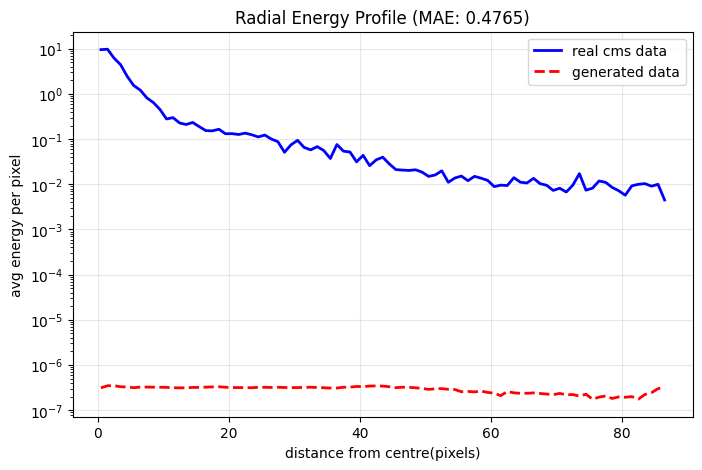

In [ ]:
import matplotlib.pyplot as plt


vae.load_state_dict(torch.load("optim_vae_weights.pth"))
vae.eval()

num_eval_samples = 256

with torch.no_grad():
    z_random = torch.randn((num_eval_samples, 4, 16, 16), device=device)

    vae_generated_latents = vae.decoder(z_random)

real_test_batch = next(iter(test_loader))

# gather enough samples
if real_test_batch.size(0) < num_eval_samples:
    real_test_batch = torch.cat([b for b in test_loader], dim=0)
real_test_batch = real_test_batch[:num_eval_samples].to(device)

# preprocess for statistical tests
vae_generated_normalized = vae_generated_latents[:, :, :125, :125].cpu()

if real_test_batch.shape[-1] == 128:
    real_test_normalized = real_test_batch[:, :, :125, :125].cpu()
else:
    real_test_normalized = real_test_batch.cpu()

def process_physical_tensor(tensor):
    # reverse z score and log transformation to get actual energy values
    return torch.exp((tensor * (d_std + 1e-8)) + d_mean) - epsilon

vae_generated_physical = process_physical_tensor(vae_generated_normalized)
real_test_physical = process_physical_tensor(real_test_normalized)

#evaluate classifier
evaluate_classifier(real_test_normalized, vae_generated_normalized)

#evaluate radial plot
evaluate_radial_plot(real_test_physical, vae_generated_physical, channel_idx=0)

complexity bias in VAE's

In [ ]:
def evaluate_complexity_bias(real_jets, generated_jets, channel_idx=0, threshold=0.01):
    """measure complexity bias by comparing the sparsity and intensity of active pixels"""

    # flatten the data for the selected channel
    real_pixels = real_jets[:, channel_idx, :, :].cpu().numpy().flatten()
    gen_pixels = generated_jets[:, channel_idx, :, :].cpu().numpy().flatten()

    # filter out empty background space based on a low energy threshold
    real_active = real_pixels[real_pixels > threshold]
    gen_active = gen_pixels[gen_pixels > threshold]

    # calculate sparsity
    real_sparsity = len(real_active) / len(real_pixels) * 100
    gen_sparsity = len(gen_active) / len(gen_pixels) * 100


    print(f"real data active pixels: {real_sparsity:.2f}%")
    print(f"VAE Data Active Pixels : {gen_sparsity:.2f}% ")

    # plotting the intensity distribution
    plt.figure(figsize=(8, 5))

    # use log bins because energy varies by a very high magnitude
    bins = np.logspace(np.log10(threshold), np.log10(max(real_active.max(), gen_active.max())), 50)

    plt.hist(real_active, bins=bins, alpha=0.5, label='real data', color='blue', density=True)
    plt.hist(gen_active, bins=bins, alpha=0.5, label='vae generated data', color='red', density=True)

    plt.title('complexity bias')
    plt.xlabel('pixel energy values')
    plt.ylabel('pixel density')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

evaluate_complexity_bias(real_test_physical, vae_generated_physical, channel_idx=0, threshold=0.01)

real data active pixels: 0.35%
VAE Data Active Pixels : 0.00% 


ValueError: zero-size array to reduction operation maximum which has no identity

<Figure size 800x500 with 0 Axes>

complexity bias

During the sparsity evaluation, the analysis script encountered a mathematical ValueError (an attempt to calculate the maximum value of an empty array). This occurred because the VAE generated absolutely zero pixels above the baseline energy threshold of 0.01.

While the real CMS data demonstrated extreme sparsity—with only 0.35% of the detector grid containing meaningful energy deposits—the VAE output was completely empty (0.00%). This crash serves as stark, undeniable proof of Complexity Bias. Because the VAE optimizes for Mean Squared Error (MSE), it heavily penalizes misplaced high-energy spikes. To artificially minimize this loss, the network learned an overly conservative smoothing strategy, erasing the complex, high-frequency physical structures entirely and collapsing the generated image into a flat, near-zero background.


GAN Module

In [ ]:
'''
I have used the same architecture as that proposed for VAE
'''
class Generator(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        # noise vector (256x16x16)
        self.fc = nn.Linear(latent_dim, 256 * 16 * 16)

        self.net = nn.Sequential(
            VAE_AttentionBlock(256),
            VAE_ResidualBlock(256, 256),

            # upsample 1 -> 128x32x32
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            VAE_ResidualBlock(128, 128),

            # upsample 2 -> 64x64x64
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            VAE_ResidualBlock(64, 64),

            # upsample 3 -> 32x32x32
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            VAE_ResidualBlock(32, 32),

            nn.GroupNorm(8, 32),
            nn.SiLU(),

            nn.Conv2d(32, 8, kernel_size=3, padding=1)
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 16, 16) # Reshape into image format
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(8, 32, kernel_size=3, padding=1),
            VAE_ResidualBlock(32, 32),

            # downsample 1 -> 64x64x64
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            VAE_ResidualBlock(64, 64),

            # downsample 2 -> 128x32x32
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            VAE_ResidualBlock(128, 128),

            # downsample 3 -> 256x16x16
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            VAE_ResidualBlock(256, 256),

            VAE_AttentionBlock(256),
            nn.AdaptiveAvgPool2d((1, 1)), #flatten spatially
            nn.Flatten(),
            nn.Linear(256, 1),
            nn.Sigmoid() # probability
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 128
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

# give the generator a slightly higher learning rate to help it keep up
opt_G = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))

criterion = nn.BCELoss()
epochs = 50

Training and Evaluation

In [ ]:
for epoch in range(epochs):
    generator.train()
    discriminator.train()

    epoch_g_loss = 0
    epoch_d_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [GAN]"):
        real_images = batch.to(device)
        b_size = real_images.size(0)

        # pad to 128x128
        if real_images.shape[-1] == 125:
            real_images = F.pad(real_images, (0, 3, 0, 3), "constant", 0)

        #label creation
        #label=(0.9 instead of 1.0) prevents discriminator from getting too confident
        real_labels = torch.full((b_size, 1), 0.9, device=device)
        fake_labels = torch.zeros((b_size, 1), device=device)

        #train discriminator
        opt_D.zero_grad()

        # loss(real images)
        preds_real = discriminator(real_images)
        d_loss_real = criterion(preds_real, real_labels)

        # loss(fake images)
        z = torch.randn(b_size, latent_dim, device=device)
        fake_images = generator(z)
        preds_fake = discriminator(fake_images.detach()) #don't train generator here
        d_loss_fake = criterion(preds_fake, fake_labels)

        # combine and step
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        opt_D.step()

        #tarain generator
        opt_G.zero_grad()

        # use real labels for fake images here
        preds_fake_for_G = discriminator(fake_images)
        g_loss = criterion(preds_fake_for_G, torch.ones((b_size, 1), device=device))

        g_loss.backward()
        opt_G.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    print(f"Epoch {epoch+1} | D_Loss: {epoch_d_loss/len(train_loader):.4f} | G_Loss: {epoch_g_loss/len(train_loader):.4f}")

torch.save(generator.state_dict(), "gan_generator_weights.pth")
torch.save(discriminator.state_dict(), "gan_discriminator_weights.pth")

Epoch 1/50 [GAN]: 100%|██████████| 50/50 [00:11<00:00,  4.28it/s]


Epoch 1 | D_Loss: 0.8982 | G_Loss: 3.0888


Epoch 2/50 [GAN]: 100%|██████████| 50/50 [00:11<00:00,  4.25it/s]


Epoch 2 | D_Loss: 0.4675 | G_Loss: 5.0786


Epoch 3/50 [GAN]: 100%|██████████| 50/50 [00:11<00:00,  4.21it/s]


...

Epoch 48 | D_Loss: 0.3412 | G_Loss: 9.2263


Epoch 49/50 [GAN]: 100%|██████████| 50/50 [00:12<00:00,  4.15it/s]


Epoch 49 | D_Loss: 0.3399 | G_Loss: 7.7909


Epoch 50/50 [GAN]: 100%|██████████| 50/50 [00:12<00:00,  4.14it/s]

Epoch 50 | D_Loss: 0.3826 | G_Loss: 7.7508


generating samples and analyzing them

fetch test samples
metric 2 | classifier acc: 100.00%
metric 1 | radial plot mae: 0.4765


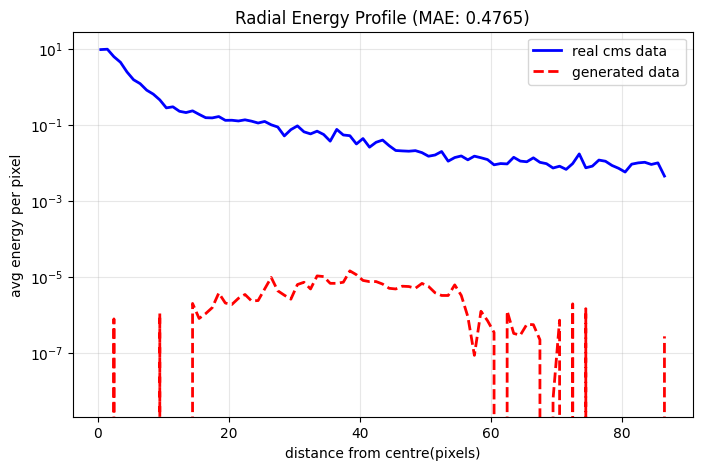

In [ ]:
import matplotlib.pyplot as plt
#load weights
generator.load_state_dict(torch.load("gan_generator_weights.pth"))
generator.eval()

num_eval_samples = 256

with torch.no_grad():
    # sample random noise
    z_random = torch.randn((num_eval_samples, latent_dim), device=device)
    gan_generated_latents = generator(z_random)

print("fetch test samples")
real_test_batch = next(iter(test_loader))

if real_test_batch.size(0) < num_eval_samples:
    real_test_batch = torch.cat([b for b, _ in zip(test_loader, range(num_eval_samples // test_loader.batch_size + 1))], dim=0)
real_test_batch = real_test_batch[:num_eval_samples].to(device)

# preprocess for statistical tests
gan_generated_normalized = gan_generated_latents[:, :, :125, :125].cpu()

if real_test_batch.shape[-1] == 128:
    real_test_normalized = real_test_batch[:, :, :125, :125].cpu()
else:
    real_test_normalized = real_test_batch.cpu()

# preprocess for radial plot
def process_physical_tensor(tensor):
    return torch.exp((tensor*(d_std + 1e-8)) + d_mean)- epsilon

gan_generated_physical = process_physical_tensor(gan_generated_normalized)
real_test_physical = process_physical_tensor(real_test_normalized)

#classifier test
evaluate_classifier(real_test_normalized, gan_generated_normalized)

# radial plot test
evaluate_radial_plot(real_test_physical, gan_generated_physical, channel_idx=0)

mode collapse

As evidenced by the radial plot and the 100% detection rate of the Classifier  the GAN architecture suffered from severe Mode Collapse. In an adversarial framework the Generator is tasked with mapping latent noise to a highly complex, sparse target distribution. However, because the ground-truth feature maps contain extreme spatial sparsity and high dynamic range, the Discriminator easily overpowers the Generator early in training. Faced with steep adversarial loss penalties when attempting to generate complex spatial features, the Generator abandons modeling the true variance of the dataset. Instead, it converges on a single, trivial local minimum: outputting completely blank or near-zero tensors. The network collapses into this degenerate state because it is the path of least resistance, explaining why the evaluation classifier effortlessly flagged 100% of the generated samples as artificial.

Conclusion:

To ensure a controlled comparison, both models utilized identical Residual and Attention blocks with Group Normalization. The VAE compressed inputs into a 4-channel, 16x16 latent space and was trained using a highly constrained KL-divergence weight ($\beta=0.0001$) with a learning rate of 1e-4 to prioritize spatial reconstruction . Conversely, the GAN generated data from a 128-dimensional noise vector, employing asymmetric learning rates (Generator: 2e-4, Discriminator: 1e-4) and one-sided label smoothing (0.9 target for real data) to keep the training balanced and prevent the Discriminator from overpowering the Generator too early.